# Imports

In [1]:
from qiskit import QuantumCircuit
from matplotlib.pyplot import figure
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
backend = AerSimulator(method='statevector')

# Ejercicio 1
phi_plus() y psi_plus() por completez

In [2]:
def phi_plus():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    return qc

def psi_plus():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.x(1)
    qc.cx(0, 1)
    return qc

def phi_minus():
    qc = QuantumCircuit(2)
    qc.x(0)
    qc.h(0)
    qc.cx(0, 1)
    return qc

def psi_minus():
    qc = QuantumCircuit(2)
    qc.x(0)
    qc.h(0)
    qc.x(0)
    qc.x(1)
    qc.cx(0, 1)
    return qc

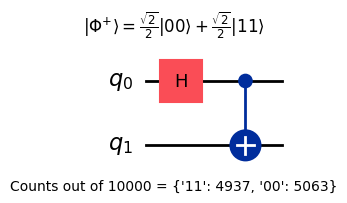

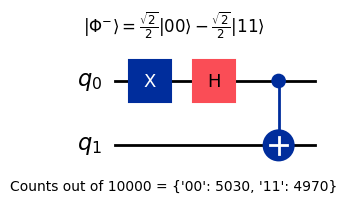

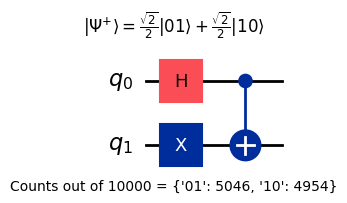

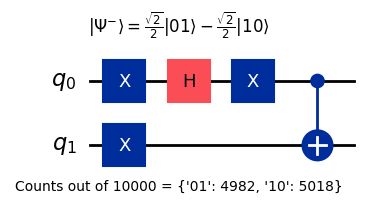

In [3]:
labels_functions = [(r"$|\Phi^{+}\rangle =", phi_plus),
                   (r"$|\Phi^{-}\rangle =", phi_minus),
                   (r"$|\Psi^{+}\rangle =", psi_plus),
                   (r"$|\Psi^{-}\rangle =", psi_minus)]

for label, function in labels_functions:
    qc = function()
    fig = figure(qc.draw(output='mpl'))
    psi = Statevector(qc)
    
    qc.measure_all()
    shots = 10000
    counts = backend.run(qc, shots=shots).result().get_counts()
    
    fig.suptitle(label + psi.draw('latex').data.replace("$", "") + "$")
    fig.text(0.5, 0.1, f"Counts out of {shots} = {counts}", ha='center',
             va='center')

# Ejercicio 2
Una fase global es un factor de fase complejo que afecta a todo el estado del sistema. Por ejemplo, para $\alpha, \theta, \phi \in \mathcal{R}$, tenemos el estado general de un qubit y su multiplicación por una fase global:
$$\ket{\psi} = \frac{1}{\sqrt{2}}\left(\sin{(\phi / 2)}\ket{0} + e^{i \phi}\cos{(\phi/2)}\ket{1}\right) \rightarrow \ket{\psi'} = e^{i \alpha} \frac{1}{\sqrt{2}}\left(\sin{(\phi / 2)}\ket{0} + e^{i \phi}\cos{(\phi/2)}\ket{1}\right).$$

Veamos que la fase global no afecta la normalización del estado,
$$\bra{\psi'} \ket{\psi'} = e^{-i \alpha} \bra{\psi} \ket{\psi} e^{i \alpha} = \bra{\psi} \ket{\psi}.$$

Ni a las probabilidades de medición ($k \in \{0, 1\}$)
$$P(\ket{\psi'} = \ket{k}) = |\bra{k} \ket{\psi'}|^2 = |e^{i\alpha} \bra{k} \ket{\psi}|^2 = |e^{i\alpha}|^2 |\bra{k} \ket{\psi}|^2 = |\bra{k} \ket{\psi}|^2 = P(\ket{\psi} = \ket{k}).$$

Veamos, sin embargo, que las fases relativas sí afectan a la medición. Por ejemplo, para $\alpha = \pi$, $\ket{\psi} = \ket{+} = \frac{1}{\sqrt{2}} (\ket{0} + \ket{1})$,
$$\ket{\psi'} = \frac{1}{\sqrt{2}} (\ket{0} + e^{i \alpha} \ket{1}) = \frac{1}{\sqrt{2}} (\ket{0} - \ket{1}) = \ket{-}.$$

Por lo que
$$P(\ket{\psi'} = \ket{+}) = |\bra{+}\ket{-}|^2 = 0 \neq 1 = |\bra{+}\ket{+}|^2 = P(\ket{\psi} = \ket{+}).$$

Referencia: https://www.quantum-applications.com/glossary/global-phase/

# Ejercicio 3

In [4]:
def qcircuit():
    qc = QuantumCircuit(3)
    qc.x(0)
    qc.barrier()
    qc.h(0)
    qc.h(1)
    qc.barrier()
    qc.cx(0, 2)
    qc.cx(1, 2)
    qc.barrier()
    
    return qc

<IPython.core.display.Latex object>

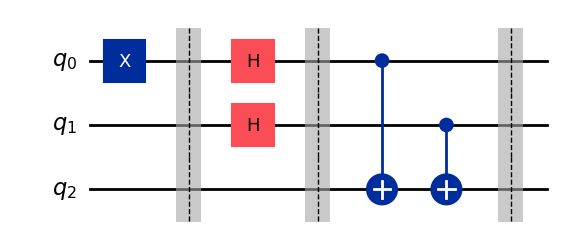

In [5]:
qc = qcircuit()

fig = figure(qc.draw(output='mpl'))
psi = Statevector(qc)
psi.draw('latex')

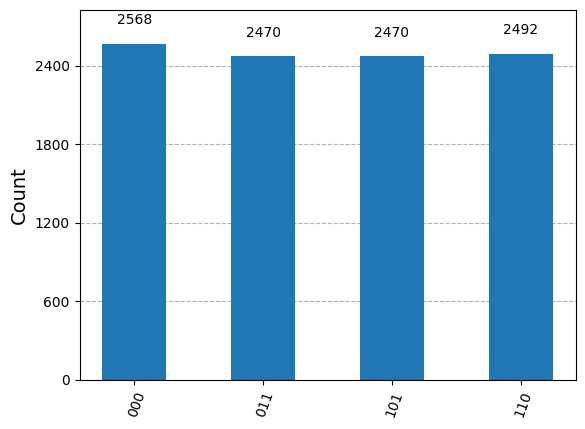

In [6]:
qc.measure_all()
shots = 10000
counts = backend.run(qc, shots=10000).result().get_counts()
plot_histogram(counts)

## Ejercicio 3 - Análisis
Para determinar el resultado de enviar $\ket{000}$ al sistema, evaluamos las compuertas en las tres \textit{barriers} mostradas por qiskit. Tras la primer barrera,

\begin{align*}
    \ket{\psi_1} = X\otimes I^{\otimes2}\ket{000} = X\ket{0}I\ket{0}I\ket{0} = \ket{1}\ket{0}\ket{0} = \ket{100}.
\end{align*}

La siguiente barrera tiene el efecto
\begin{align*}
    \ket{\psi_2} &= H^{\otimes 2}\otimes I \ket{100} = H\ket{1}H\ket{0}H\ket{0} = \ket{-}\ket{+}\ket{0} \\
    &= \frac{1}{2}(\ket{0} - \ket{1})(\ket{0} + \ket{1}) \ket{0} = \frac{1}{2}(\ket{000} + \ket{010} - \ket{100} - \ket{110}),
\end{align*}

donde usamos que la compuerta de Hadamard es $H = \ketbra{+}{0} + \ketbra{-}{1}$.

Finalmente, la tercer barrera aplica dos CNOTs, que denotaré $\dot{X}_{ij,n}$, siendo $i$ el qubit de control, $j$ el qubit objetivo y $n$ el número de qubits en el circuito (y enumero al revés que \textit{qiskit}). Tenemos entonces $\dot{X}_{02,3} = \ketbra{1}{1}\otimes I \otimes X + \ketbra{0}{0} \otimes I \otimes I$, $\dot{X}_{12,3} = I\otimes (\ketbra{1}{1}\otimes X + \ketbra{0}{0}\otimes I)$. La aplicación del primer CNOT produce
\begin{align*}
    \ket{\psi_{13}} &= \dot{X}_{02,3}\frac{1}{2}(\ket{000} + \ket{010} - \ket{100} - \ket{110}) \\
    &= \frac{1}{2}(\ket{0}I\ket{0}I\ket{0} + \ket{0}I\ket{1}I\ket{0} - \ket{1}I\ket{0}X\ket{0} - \ket{1}I\ket{1}X\ket{0}) \\&= \frac{1}{2}(\ket{0}\ket{0}\ket{0} + \ket{0}\ket{1}\ket{0} - \ket{1}\ket{0}\ket{1} - \ket{1}\ket{1}\ket{1}) \\
    & = \frac{1}{2}(\ket{000} + \ket{010} - \ket{101} - \ket{111})
\end{align*}

Mientras que para el segundo,

\begin{align*}
    \ket{\psi_{32}} &= \dot{X}_{12,3}\frac{1}{2}(\ket{000} + \ket{010} - \ket{101} - \ket{111}) \\
    &= \frac{1}{2}(I\ket{0}\ket{0}I\ket{0} + I\ket{0}\ket{1}X\ket{0} - I\ket{1}\ket{0}\ket{1} - I\ket{1}\ket{1}X\ket{1}) \\&= \frac{1}{2}(\ket{0}\ket{0}\ket{0} + \ket{0}\ket{1}\ket{1} - \ket{1}\ket{0}\ket{1} - \ket{1}\ket{1}\ket{0}) \\
    & = \frac{1}{2}(\ket{000} + \ket{011} - \ket{101} - \ket{110}).
\end{align*}

Siendo éste nuestro resultado final que coincide con el vector de estado de \textit{qiskit}. Además, la probabilidad de medir cada uno de los cuatro vectores es $(1/2)^2 = 1/4$, valores a los que tiende el histograma de cuentas.
